In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline

In [ ]:
#General RK4 method
def RK4(y, dty, t, dt, x):
  k1 = dty(t, y, x)
  k2 = dty(t + (0.5*dt), y + 0.5*dt*k1, x)
  k3 = dty(t + (0.5*dt), y + 0.5*dt*k2, x)
  k4 = dty(t + dt, y + dt*k3, x)

  y = y + (dt/6)*(k1+2*(k2+k3)+k4)
  t = t + dt
  return (y, t)

def dxy_2nd_P(y, x): # boundary conditions here are periodic
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # centered difference non boundary
    dyx[1:-1] = (y[2:] - y[:-2]) / (2 * h)

    # boundaries using periodic stuff
    dyx[0] = (y[1] - y[-1]) / (2 * h)
    dyx[-1] = (y[0] - y[-2]) / (2 * h)
    return dyx

def dxy_2nd_D(y, x, y_left=0.0, y_right=0.0):
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # ghost points from Dirichlet BCs
    y_ghost_left = 2 * y_left - y[0]
    y_ghost_right = 2 * y_right - y[-1]

    # pad array with ghost points
    y_ext = np.concatenate(([y_ghost_left], y, [y_ghost_right]))

    # centered difference using ghost points
    dyx[:] = (y_ext[2:] - y_ext[:-2]) / (2 * h)
    return dyx

def dxy_2nd_D_2nd(y, x, y_left=0.0, y_right=0.0): # second order and second differential with Dirichlet BCs
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # ghost points from Dirichlet BCs due to staggered grid
    y_ghost_left = 2 * y_left - y[0]
    y_ghost_right = 2 * y_right - y[-1]

    # centered difference using ghost points
    dyx[1:-1] = (y[2:] + y[:-2] - 2*y[1:-1]) / (h*h)
    dyx[0]    = (y[1] + y_ghost_left -2*y[0] ) / (h*h)
    dyx[-1]   = (y[-2] + y_ghost_right -2*y[-1] ) / (h*h)
    return dyx


def dxy_2nd_P_2nd(y, x): # boundary conditions here are periodic
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # centered difference non boundary
    dyx[1:-1] = (y[2:] + y[:-2] - 2*y[1:-1]) / (h*h)

    # boundaries using periodic stuff
    dyx[0] = (y[1] + y[-1] - 2*y[0]) / (h*h)
    dyx[-1] = (y[0] + y[-2] - 2*y[-1]) / (h*h)
    return dyx

def dxy_4th_P(y, x): # boundary conditions here are periodic
  h = x[1] - x[0]
  dyx = np.zeros_like(y)
  h12_inverse = 1 / (12 * h)
  # centered difference non boundary
  dyx[2:-2] = (-y[4:] + 8*y[3:-1] - 8*y[1:-3] + y[:-4]) * h12_inverse

  # boundaries using periodic stuff
  dyx[0] = (-y[2] + 8*(y[1] - y[-1]) + y[-2]) * h12_inverse
  dyx[1] = (-y[3] + 8*(y[2] - y[0]) + y[-1]) * h12_inverse
  dyx[-1] = (-y[1] + 8*(y[0] - y[-2]) + y[-3]) * h12_inverse
  dyx[-2] = (-y[0] + 8*(y[-1] - y[-3]) + y[-4]) * h12_inverse
  return dyx

def dxy_2nd_N_2nd(y, x, dydx_left = 0.0, dydx_right = 0.0):
    h = x[1] - x[0]
    inv_h2 = 1.0 / (h*h)

    # Left ghost: (y0 - y_ghost)/(2h) = dydx_left
    y_ghost_left = y[0] - 2.0*h*dydx_left

    # Right ghost: (y_ghost - y_last)/(2h) = dydx_right
    y_ghost_right = y[-1] + 2.0*h*dydx_right

    # Extend grid
    y_ext = np.concatenate(([y_ghost_left], y, [y_ghost_right]))

    # Centered second difference
    return (y_ext[2:] - 2*y_ext[1:-1] + y_ext[:-2]) * inv_h2

def make_staggeredx(xnum):
  x = np.linspace(0, (xnum-1)/xnum , xnum)
  x += 1/(2*xnum)
  return x


In [ ]:
def get_grad_non_conformal(vars, grid):
  gradishs = np.ndarray(shape = [4,xnum])
  gradishs[0] = dxy_2nd_D(vars[0], grid, y_left = 1, y_right = 1)
  gradishs[1] = dxy_2nd_D(vars[1], grid, y_left = 0.0025, y_right = 1.0025)
  gradishs[2] = dxy_2nd_D(vars[2], grid)
  gradishs[3] = dxy_2nd_D(vars[3], grid)
  return (gradishs)


def get_rates_non_conformal(rates, vars, lapse, shift, grid):
  grad_shift = dxy_2nd_D(shift, grid)
  gradishs = get_grad_non_conformal(vars, grid)
  second_b = dxy_2nd_D_2nd(vars[1], grid,y_left = 0.0025, y_right = 1.0025) #second derivative of b
  grad_lapse = dxy_2nd_D(lapse, grid, y_left = 1, y_right = 1)
  second_lapse = dxy_2nd_D_2nd(lapse, grid, y_left = 1, y_right = 1)

  #actual PDEs
  rates[0] = (shift * gradishs[0]) + 2*(vars[0]*grad_shift - lapse*vars[2])
  rates[1] = shift * gradishs[1] - 2*lapse*vars[3]
  rates[2] = lapse* (-(vars[2]*vars[2]/vars[0]) + (2*vars[3]*vars[2]/vars[1]) + 0.5*((gradishs[1]*gradishs[1])/(vars[1]*vars[1]) + (gradishs[0]*gradishs[1])/(vars[0]*vars[1])) - (second_b/vars[1]))
  + (2*grad_shift*vars[2]) + (shift * gradishs[2]) - second_lapse + 0.5*(gradishs[0]*grad_lapse/vars[0])

  rates[3] = (1/vars[0])*((vars[2]*vars[3]*lapse) + (gradishs[0]*gradishs[1]*lapse/(4*vars[0])) - (0.5*second_b*lapse) - (0.5*grad_lapse*gradishs[1]/vars[0])) + lapse + shift*gradishs[3]
  return (rates)

def get_grad(vars, grid): # conformal version
  gradishs = np.ndarray(shape = [4,xnum])
  gradishs[0] = dxy_2nd_D(vars[0], grid, y_left = 1, y_right = 1)
  gradishs[1] = dxy_2nd_D(vars[1], grid, y_left = 1, y_right = 1)
  gradishs[2] = dxy_2nd_D(vars[2], grid, y_left = 0, y_right = 0)
  gradishs[3] = dxy_2nd_D(vars[3], grid, y_left = 0, y_right = 0)
  return (gradishs)


def get_rates(rates, vars, lapse, shift, grid): # this version is for a conformal b
  grad_shift = dxy_2nd_D(shift, grid)
  gradishs = get_grad(vars, grid)
  r_squared = grid * grid

  b = vars[1] * r_squared
  first_b = 2*grid*vars[1] + r_squared*gradishs[1] #first derivative of b
  second_b = (r_squared * dxy_2nd_D_2nd(vars[1], grid, y_left = 1, y_right = 1) + 4*grid*gradishs[1] + 2*vars[1]) #second derivative of b

  grad_lapse = dxy_2nd_D(lapse, grid, y_left = 1, y_right = 1)
  second_lapse = dxy_2nd_D_2nd(lapse, grid, y_left = 1, y_right = 1)


  #actual PDEs
  rates[0] = (shift * gradishs[0]) + 2*(vars[0]*grad_shift - lapse*vars[2])
  rates[1] = (shift * first_b - 2*lapse*vars[3]) / r_squared

  rates[2] = lapse* (-(vars[2]*vars[2]/vars[0]) + ((2*vars[3]*vars[2]) + 0.5*((first_b*first_b)/(b) + (gradishs[0]*first_b)/(vars[0])) - (second_b))/b)
  + (2*grad_shift*vars[2]) + (shift * gradishs[2]) - second_lapse + 0.5*(gradishs[0]*grad_lapse/vars[0])
  rates[3] = (1/vars[0])*((vars[2]*vars[3]*lapse) + (0.25*gradishs[0]*first_b*lapse/(vars[0])) - (0.5*second_b*lapse) - (0.5*grad_lapse*first_b/vars[0])) + lapse + shift*gradishs[3]

  return (rates)

In [ ]:
#create a set of arrays for the components a, b, c, and d
xnum = 30
vars = np.ndarray(shape = [4,xnum], dtype=np.double) # a, b, c and d are the "ith" row
gradishs = np.ndarray(shape = [4,xnum], dtype=np.double) # partial derivatives with respect to r
rates = np.ndarray(shape = [4,xnum], dtype=np.double) # partial derivatives with respect to time for the vars

for i in range(2,4):
  vars[i] = np.zeros(xnum, dtype=np.double)

x = make_staggeredx(xnum)
vars[0] = np.ones(xnum, dtype=np.double) #* (0.1*np.sin(np.pi*x)**2  + 1) # Initialize a to ones
vars[1] = np.ones(xnum, dtype=np.double)# * (0.1*np.sin(np.pi*x)**2  + 1)
#vars[3] = 0.1*np.sin(np.pi*x)**2
print(vars)

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]


In [ ]:
# Create arrays for lapse and shift with the same shape as the variables
lapse_arr = np.full(xnum, 1.0)
shift_arr = np.full(xnum, 0.0)

rates = get_rates(rates, vars, lapse_arr, shift_arr, x)
print(rates)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]


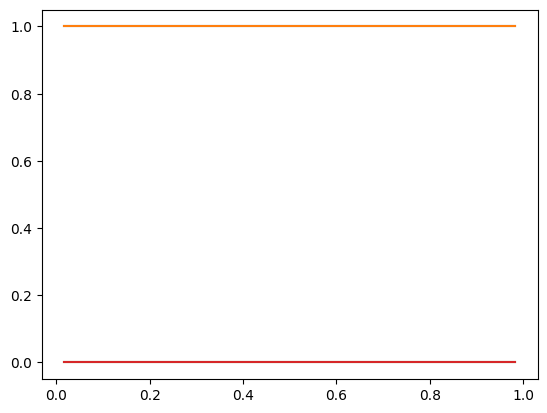

In [ ]:
plt.plot(x, vars[0])
plt.plot(x, vars[1])
plt.plot(x, vars[2])
plt.plot(x, vars[3])

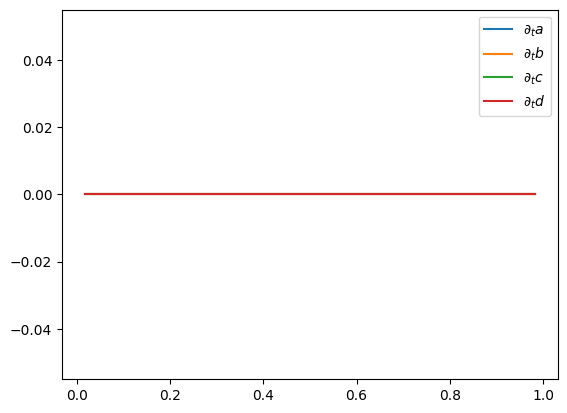

In [ ]:
plt.plot(x, rates[0][:],label = r'$\partial_t a$')
plt.plot(x, rates[1][:],label = r'$\partial_t b$')
plt.plot(x, rates[2][:],label = r'$\partial_t c$')
plt.plot(x, rates[3][:],label = r'$\partial_t d$')

plt.legend(loc = 'best')